<a href="https://colab.research.google.com/github/mpatel5/CSCI_221_Final_Project/blob/main/Part1_Multilinear_Regression_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Multi-Linear Regression in Python
* Dataset: developer_burnout.csv
* Target Variable: burnout_level

# Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm

# Load dataset

In [54]:
df = pd.read_csv("developer_burnout.csv")

# Preview the data

In [55]:
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nColumn names:")
print(df.columns)

First 5 rows:
    age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  26.0              12.0             10.33         4.45              2.0   
1  39.0              10.0              8.62         5.77              5.0   
2  34.0              13.0               NaN         4.03              5.0   
3  30.0               1.0              6.85         6.47              2.0   
4  27.0               7.0              4.24         5.80              NaN   

   bugs_per_day  commits_per_day  meetings_per_day  screen_time  \
0          11.0              4.0               1.0        15.07   
1          15.0             11.0               5.0        13.25   
2           2.0             18.0               9.0        11.18   
3          15.0             26.0               1.0        11.14   
4           9.0             17.0               7.0         8.05   

   exercise_hours  stress_level burnout_level  
0            0.14         55.96        Medium  
1            0.54       

# Visualization of the data

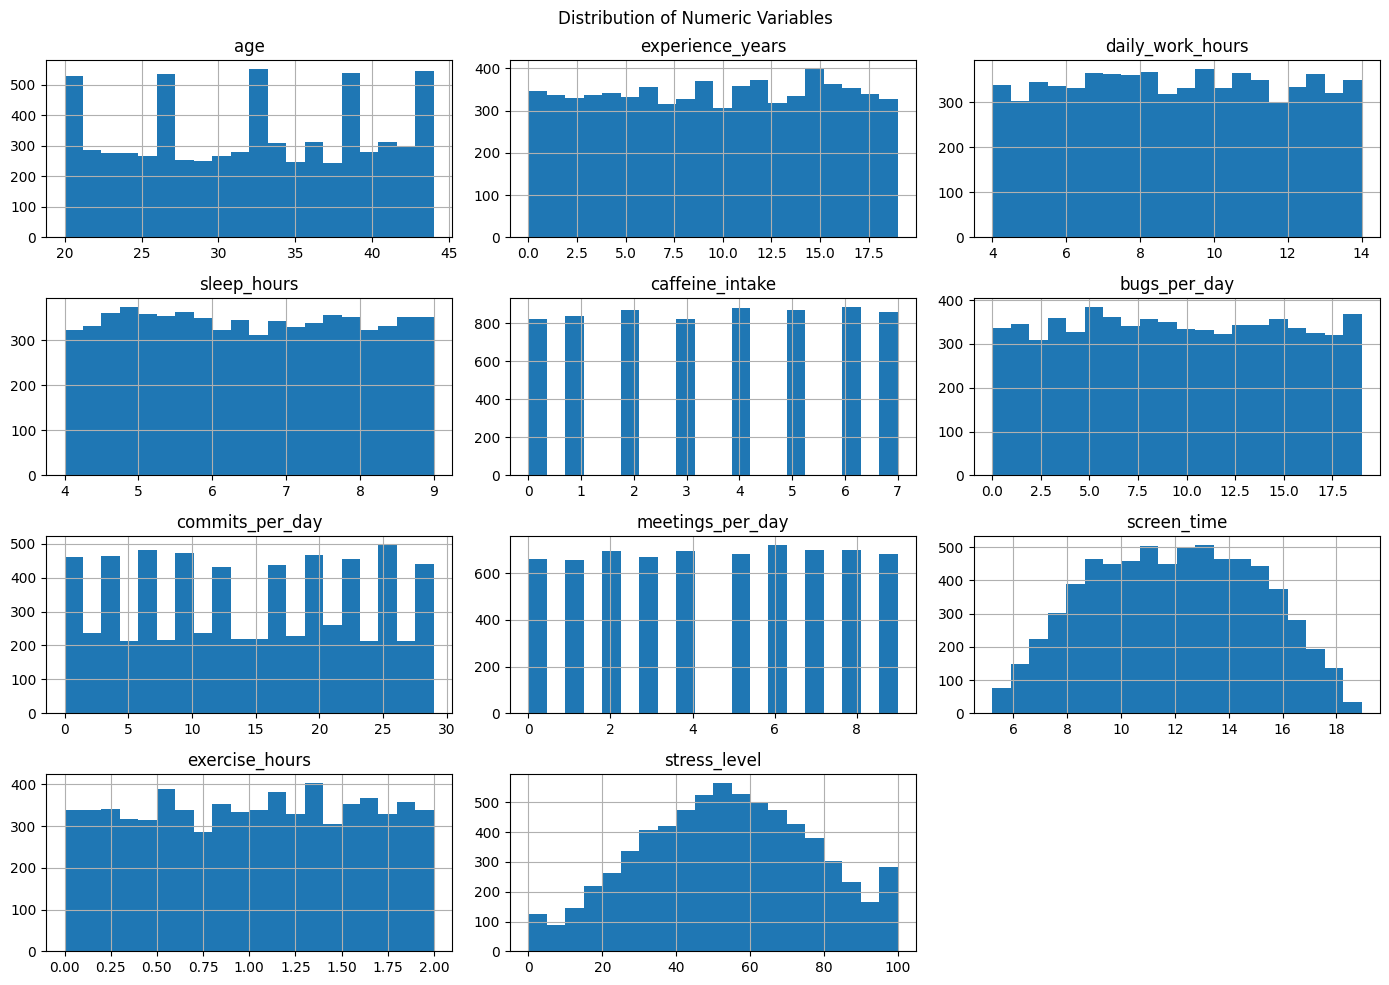

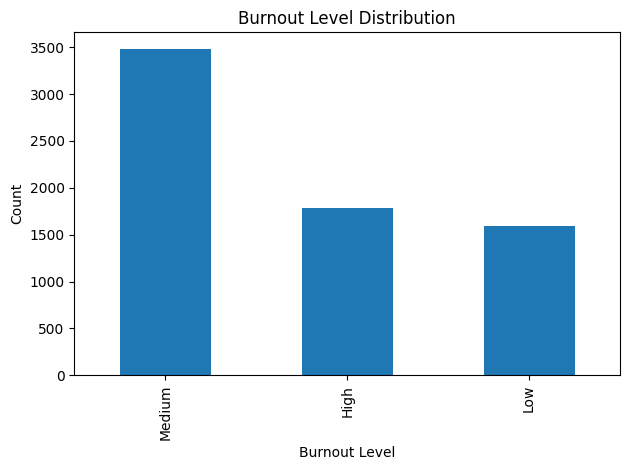

In [56]:
numeric_cols = df.select_dtypes(include=["number"]).columns

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribution of Numeric Variables")
plt.tight_layout()
plt.show()

df["burnout_level"].value_counts().plot(kind="bar")
plt.title("Burnout Level Distribution")
plt.xlabel("Burnout Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Check for duplicates

In [57]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate rows found, so no removal was necessary.")
else:
    df = df.drop_duplicates()
    print("Duplicate rows were removed.")


Duplicate rows: 0
No duplicate rows found, so no removal was necessary.


# Check for missing values and impute missing values

* I used median imputation for missing numeric values because the median is less affected by extreme values or skewed data than the mean. Since variables like work hours, screen time, stress level, sleep, and exercise may not be perfectly normally distributed, the median gives a more stable replacement value.

* Rows with missing burnout_level were removed because burnout_level is the target variable. Imputing the outcome could artificially create labels and bias the regression model.

In [58]:
# Check for missing values
print("\nMissing values:")
print(df.isna().sum())

# Fill missing numeric predictor values with median
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Drop rows where the target variable is missing
df = df.dropna(subset=["burnout_level"])


Missing values:
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64


# Check outliers


--- IQR Outlier Detection ---
age: 0 outliers
experience_years: 0 outliers
daily_work_hours: 0 outliers
sleep_hours: 0 outliers
caffeine_intake: 0 outliers
bugs_per_day: 0 outliers
commits_per_day: 0 outliers
meetings_per_day: 0 outliers
screen_time: 0 outliers
exercise_hours: 0 outliers
stress_level: 0 outliers

--- Z-Score Outlier Detection ---
age: 0 outliers
experience_years: 0 outliers
daily_work_hours: 0 outliers
sleep_hours: 0 outliers
caffeine_intake: 0 outliers
bugs_per_day: 0 outliers
commits_per_day: 0 outliers
meetings_per_day: 0 outliers
screen_time: 0 outliers
exercise_hours: 0 outliers
stress_level: 0 outliers

--- Outlier Comparison Summary ---
age → IQR: 0 | Z-score: 0
experience_years → IQR: 0 | Z-score: 0
daily_work_hours → IQR: 0 | Z-score: 0
sleep_hours → IQR: 0 | Z-score: 0
caffeine_intake → IQR: 0 | Z-score: 0
bugs_per_day → IQR: 0 | Z-score: 0
commits_per_day → IQR: 0 | Z-score: 0
meetings_per_day → IQR: 0 | Z-score: 0
screen_time → IQR: 0 | Z-score: 0
exercise

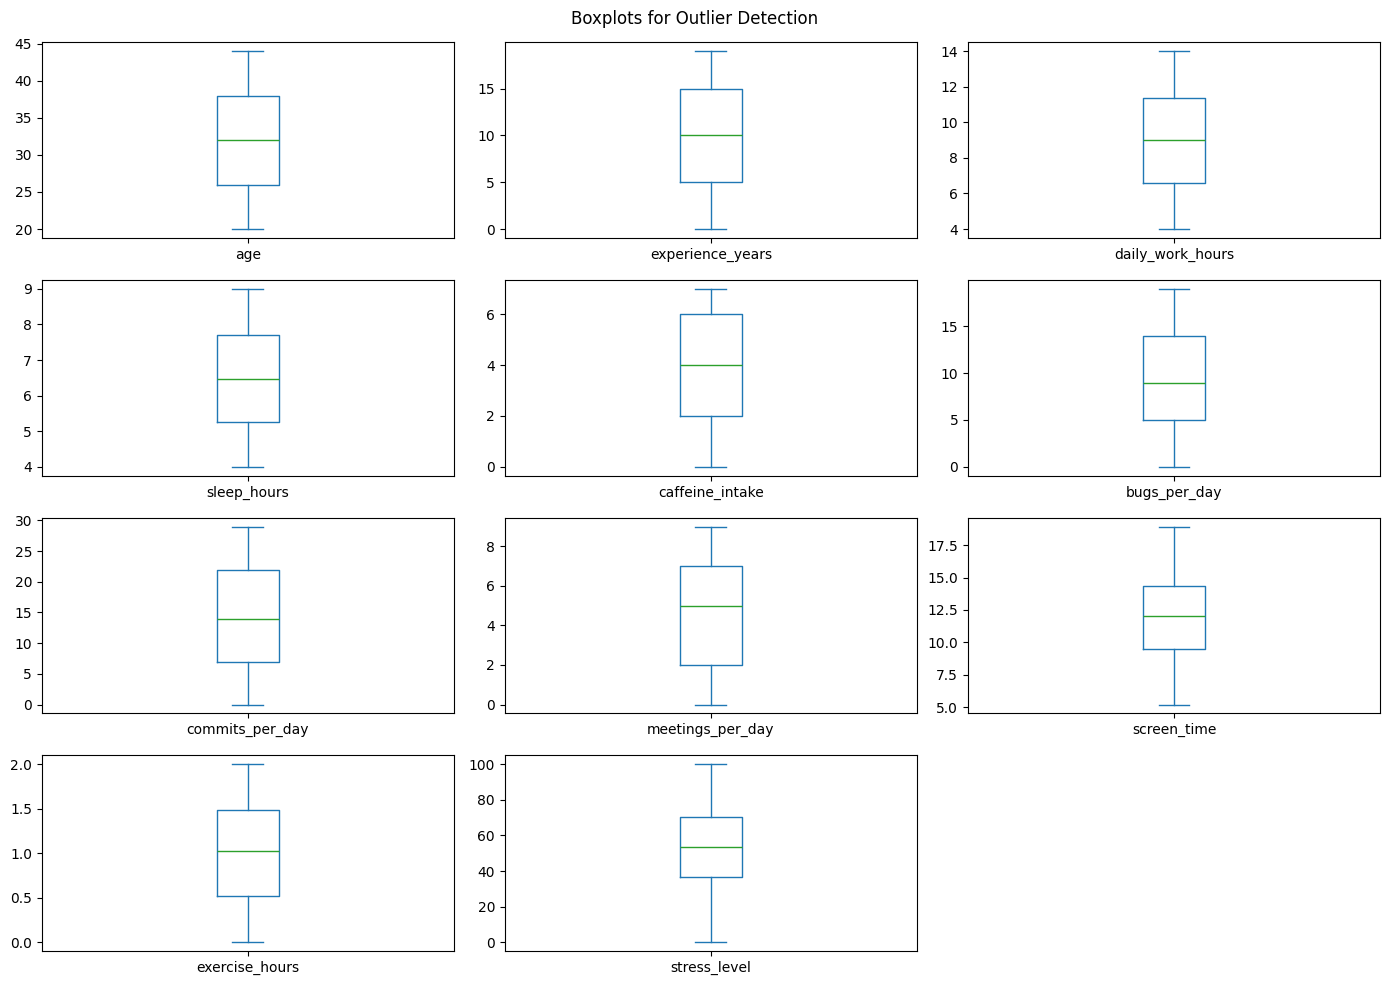

In [59]:
# IQR Method
numeric_cols = df.select_dtypes(include=["number"]).columns

print("\n--- IQR Outlier Detection ---")

iqr_outliers = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    iqr_outliers[col] = count

    print(f"{col}: {count} outliers")

# Z-Score Method
print("\n--- Z-Score Outlier Detection ---")

z_scores = np.abs(zscore(df[numeric_cols]))

z_outliers = {}

for i, col in enumerate(numeric_cols):
    count = (z_scores[:, i] > 3).sum()
    z_outliers[col] = count

    print(f"{col}: {count} outliers")

print("\n--- Outlier Comparison Summary ---")

for col in numeric_cols:
    print(f"{col} → IQR: {iqr_outliers[col]} | Z-score: {z_outliers[col]}")

# Boxplots for visual confirmation
df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(4, 3),
    figsize=(14, 10),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outlier Detection")
plt.tight_layout()
plt.show()

# Outliers were analyzed using both the IQR method and Z-score method.
* The IQR method identifies outliers using quartiles, while the Z-score method identifies values more than 3 standard deviations from the mean.
* Both methods produced similar results, and no significant outliers were detected, so no removal was necessary.


# Convert target variable

* The target variable was encoded numerically to allow regression modeling while preserving the ordinal relationship between burnout levels.

In [60]:
burnout_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

df["burnout_level"] = df["burnout_level"].map(burnout_mapping)

print("\nBurnout level after numeric conversion:")
print(df["burnout_level"].value_counts())


Burnout level after numeric conversion:
burnout_level
2    3485
3    1782
1    1593
Name: count, dtype: int64


# Select predictors and target

* The predictor variables were selected because they are reasonably connected to burnout. Daily work hours and stress level represent work-related pressure, while sleep hours, exercise hours, and screen time represent lifestyle and recovery factors. Using several predictors helps the model explain burnout from both job-related and personal factors.

In [61]:
predictor_columns = [
    "daily_work_hours",
    "sleep_hours",
    "stress_level",
    "screen_time",
    "exercise_hours"
]

X = df[predictor_columns]
y = df["burnout_level"]

# Train-test split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Fit linear regression model


In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Make predictions

In [64]:
y_pred = model.predict(X_test)

# Evaluate model

In [65]:
r2 = model.score(X_test, y_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = len(y_test)
p = X.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\nModel Performance:")
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)
print("RMSE:", rmse)
print("R² as percentage:", round(r2 * 100, 2), "%")

print("\nInterpretation:")
print("The model explains approximately 81% of the variation in burnout level, indicating a strong relationship between the predictors and burnout.")


Model Performance:
R²: 0.8131580057463802
Adjusted R²: 0.8124741038640463
RMSE: 0.30134897049539267
R² as percentage: 81.32 %

Interpretation:
The model explains approximately 81% of the variation in burnout level, indicating a strong relationship between the predictors and burnout.


# Coefficients

# Coefficient interpretation:
* Each coefficient shows how much the predicted burnout_level changes when that predictor increases by 1 unit, assuming all other predictors stay constant.

* A positive coefficient means the predictor is associated with higher burnout.
* A negative coefficient means the predictor is associated with lower burnout.

* For example, if stress_level has a positive coefficient, then higher stress is associated with higher predicted burnout. If sleep_hours has a negative coefficient, then more sleep is associated with lower predicted burnout.



In [66]:
coefficients = pd.DataFrame({
    "Predictor": predictor_columns,
    "Coefficient": model.coef_
})

print("\nRegression Coefficients:")
print(coefficients)

print("\nIntercept:", model.intercept_)


Regression Coefficients:
          Predictor  Coefficient
0  daily_work_hours     0.001676
1       sleep_hours     0.000596
2      stress_level     0.026881
3       screen_time     0.001900
4    exercise_hours    -0.001742

Intercept: 0.5479720003002548


# Regression equation

In [67]:
equation = f"burnout_level = {model.intercept_:.4f}"

for predictor, coefficient in zip(predictor_columns, model.coef_):
    equation += f" + ({coefficient:.4f} * {predictor})"

print("\nRegression Equation:")
print(equation)


Regression Equation:
burnout_level = 0.5480 + (0.0017 * daily_work_hours) + (0.0006 * sleep_hours) + (0.0269 * stress_level) + (0.0019 * screen_time) + (-0.0017 * exercise_hours)


# Statistical significance using statsmodels

In [68]:
X_with_constant = sm.add_constant(X)

stats_model = sm.OLS(y, X_with_constant).fit()

print("\nStatsmodels Regression Summary:")
print(stats_model.summary())


Statsmodels Regression Summary:
                            OLS Regression Results                            
Dep. Variable:          burnout_level   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     6159.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:36:23   Log-Likelihood:                -1452.8
No. Observations:                6860   AIC:                             2918.
Df Residuals:                    6854   BIC:                             2959.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

# Actual vs predicted visualization

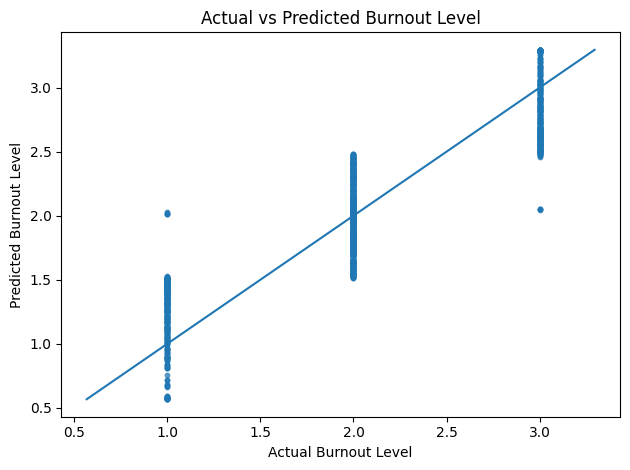

In [69]:
# Actual vs Predicted with reference line
plt.scatter(y_test, y_pred, alpha=0.7, s=10)

# Add perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.title("Actual vs Predicted Burnout Level")
plt.xlabel("Actual Burnout Level")
plt.ylabel("Predicted Burnout Level")

plt.tight_layout()
plt.show()

# Python vs R comparison:
* Python and R produced very similar regression results because both analyses used the same developer burnout dataset, target variable, and predictor variables. In Python, the model produced an R² of 0.8132, an adjusted R² of 0.8125, an RMSE of 0.3013, and an R² of 81.32%. In R, the model produced a Training R² of 0.8203, an adjusted R² of 0.8201, a Test R² of 0.8076, and an RMSE of 0.3026.

* The results are highly consistent across both languages. The R² values in both Python and R are around 0.81, indicating that approximately 81% of the variation in burnout_level is explained by the model. The RMSE values are also nearly identical (about 0.30), showing that both models have similar prediction error. The small differences in values are expected due to differences in how Python and R perform train-test splitting and internal numerical calculations.

* Both models used daily_work_hours, sleep_hours, stress_level, screen_time, and exercise_hours as predictors, and the results confirm that burnout is influenced by both work-related factors and lifestyle factors. Python was useful for the machine learning workflow using scikit-learn, while R was useful for statistical interpretation because lm() provides detailed outputs such as coefficients, p-values, R², and adjusted R².